In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.optimize import curve_fit

%matplotlib widget
plt.rc('font', family='serif')
plt.rc('xtick', labelsize=14)
plt.rc('ytick', labelsize=14)
plt.rc('axes', titlesize=16, labelsize=16)
plt.rc('legend', fontsize=14)
plt.rc('figure', titlesize=18)

In [16]:
def lorentzian(delta_MHz, linewidth_MHz):
    """Peak-normalized Lorentzian: 1 on resonance, 0.5 at delta = +/- linewidth/2."""
    half = linewidth_MHz / 2
    return half**2 / (delta_MHz**2 + half**2)


def drift_noise(n, fs_Hz, rms_V, corner_Hz, rng, alpha=2):
    """Slow drift. Power spectral density ~ 1/f^alpha below corner_Hz,
    falling an extra 40 dB/decade above. Zero mean, scaled to rms_V over the record."""
    if rms_V == 0:
        return np.zeros(n)

    # frequency of each FFT bin, DC to Nyquist
    f = np.fft.rfftfreq(n, d=1 / fs_Hz)

    # white noise in the frequency domain: random amplitude and phase in every bin
    spec = rng.standard_normal(f.size) + 1j * rng.standard_normal(f.size)

    # no DC term -> zero mean
    spec[0] = 0

    # shape the spectrum (amplitude, so power exponents are doubled):
    #   f^(-alpha/2) in amplitude           -> 1/f^alpha in power
    #   1 / (1 + (f/corner)^2) in amplitude -> flat below corner, extra 1/f^4 in power
    #                                          (40 dB/decade) above corner
    spec[1:] *= f[1:]**(-alpha / 2) / (1 + (f[1:] / corner_Hz)**2)

    # back to the time domain (real signal, length n)
    x = np.fft.irfft(spec, n=n)

    # set the total rms over the record; the spectrum shape sets how it's distributed in frequency
    return rms_V * x / np.std(x)


def white_noise(n, fs_Hz, asd_V_rtHz, hpf_Hz=None, lpf_Hz=None, rng=None,
                notch_center_Hz=None, notch_span_Hz=None):
    """White noise with amplitude spectral density asd_V_rtHz [V/rtHz].

    Optional ideal (brick-wall) cuts, done in the FFT:
      hpf_Hz:          remove everything below this. None -> keep from DC.
      lpf_Hz:          remove everything above this. None -> keep up to Nyquist.
      notch_center_Hz, notch_span_Hz: remove the band center +/- span/2.
                       None (either one) -> no notch.

    Nothing exists above Nyquist (fs/2): the noise is built directly on the sample
    grid, and a sequence sampled at fs can only represent frequencies from 0 to fs/2.
    Any higher frequency would be indistinguishable from (alias onto) one below fs/2,
    so all of the noise is placed in 0..fs/2 from the start. This does not model
    broadband noise above Nyquist folding in; lpf_Hz above fs/2 has no effect."""
    rng = np.random.default_rng() if rng is None else rng

    # unit-variance white noise sampled at fs has one-sided density sqrt(2/fs) [1/rtHz];
    # scaling by asd * sqrt(fs/2) gives a flat density of asd_V_rtHz from DC to fs/2
    x = rng.standard_normal(n) * asd_V_rtHz * np.sqrt(fs_Hz / 2)

    use_notch = notch_center_Hz is not None and notch_span_Hz is not None
    if hpf_Hz is not None or lpf_Hz is not None or use_notch:
        # to the frequency domain; f is the frequency of each bin, DC to Nyquist
        X = np.fft.rfft(x)
        f = np.fft.rfftfreq(n, 1 / fs_Hz)

        # zero the bins outside the pass band; bins inside keep their density
        if hpf_Hz is not None:
            X[f < hpf_Hz] = 0
        if lpf_Hz is not None:
            X[f > lpf_Hz] = 0
        if use_notch:
            X[np.abs(f - notch_center_Hz) <= notch_span_Hz / 2] = 0

        # back to the time domain (real signal, length n)
        x = np.fft.irfft(X, n=n)

    return x


def tof_dip(t, delta_MHz=0.0, dip_depth_V=0.150, t0_s=0.050, sigma_t_s=0.005, linewidth_MHz=5.2):
    """Atomic absorption dip [V] (positive). Photodiode sees background - dip.
    delta_MHz: scalar, or array same length as t."""
    delta = np.broadcast_to(np.asarray(delta_MHz, dtype=float), t.shape)
    envelope = np.exp(-0.5 * ((t - t0_s) / sigma_t_s)**2)
    return dip_depth_V * envelope * lorentzian(delta, linewidth_MHz)


def tof_background(
    t,
    baseline_V=9.0,
    white_asd_V_rtHz=22.4e-6,   # white noise density [V/rtHz]
    white_hpf_Hz=None,          # white noise only above this (None -> from DC)
    white_lpf_Hz=None,          # white noise only below this (None -> up to Nyquist)
    drift_rms_V=0.0,            # slow drift (air on fiber coupling), total RMS over the record
    drift_corner_Hz=50.0,       # drift rolls off steeply above this
    slow_amp_V=0.0,             # slow background sinusoid, peak amplitude
    slow_freq_Hz=100.0,
    slow_phase_rad=None,        # None -> random phase
    seed=None,
    return_parts=False,
):
    rng = np.random.default_rng(seed)
    fs_Hz = 1 / (t[1] - t[0])
    n = t.size
    if slow_phase_rad is None:
        slow_phase_rad = rng.uniform(0, 2 * np.pi)
    slow = slow_amp_V * np.sin(2 * np.pi * slow_freq_Hz * t + slow_phase_rad)
    white = white_noise(n, fs_Hz, white_asd_V_rtHz, white_hpf_Hz, white_lpf_Hz, rng)
    drift = drift_noise(n, fs_Hz, drift_rms_V, drift_corner_Hz, rng)
    bg = baseline_V + slow + white + drift
    if return_parts:
        return bg, dict(slow=slow, white=white, drift=drift)
    return bg


def digitize(v, adc_range_V=10.0, adc_bits=16):
    """Round to least significant bit, clip to +/- adc_range_V."""
    lsb = 2 * adc_range_V / 2**adc_bits
    return np.clip(np.round(v / lsb) * lsb, -adc_range_V, adc_range_V - lsb)


def modulation(t, amp_MHz=10.0, freq_Hz=2e3, dc_MHz=0.0, phase_rad=0.0):
    """True laser detuning from resonance [MHz]: dc + amp*sin(2 pi f t + phase).
    dc_MHz = 0 is centered on the atomic resonance."""
    return dc_MHz + amp_MHz * np.sin(2 * np.pi * freq_Hz * t + phase_rad)


def square_modulation(t, on_MHz=0.0, off_MHz=20.0, freq_Hz=8e3, phase_rad=0.0):
    """True laser detuning [MHz]: on_MHz while sin(2 pi f t + phase) > 0, off_MHz otherwise.
    Instantaneous switching; no laser settling, no power step."""
    theta = 2 * np.pi * freq_Hz * t + phase_rad
    return np.where(np.sin(theta) > 0, on_MHz, off_MHz)


def digitize_modulation(
    delta_MHz,
    MHz_per_V=1000.0,       # tuning coefficient: 10 mV -> 10 MHz
    white_rms_V=0.2e-3,     # noise on the modulation channel
    adc_range_V=10.0,
    adc_bits=16,
    seed=None,
):
    """Convert detuning to modulation voltage, add white noise, digitize.
    Returns (v_digitized [V], delta_digitized [MHz])."""
    rng = np.random.default_rng(seed)
    delta_MHz = np.asarray(delta_MHz, dtype=float)
    v_analog = delta_MHz / MHz_per_V + white_rms_V * rng.standard_normal(delta_MHz.shape)
    v = digitize(v_analog, adc_range_V, adc_bits)
    return v, v * MHz_per_V


def fit_reference(t, v_ref, f_guess_Hz):
    """Fit v_ref = offset + amp*sin(2 pi f t + phase)."""
    def model(t, f, a, b, c):
        w = 2 * np.pi * f * t
        return c + a * np.sin(w) + b * np.cos(w)

    # linear least squares at the guessed frequency -> starting values
    w = 2 * np.pi * f_guess_Hz * t
    M = np.column_stack([np.sin(w), np.cos(w), np.ones_like(t)])
    a0, b0, c0 = np.linalg.lstsq(M, v_ref, rcond=None)[0]

    p, cov = curve_fit(model, t, v_ref, p0=[f_guess_Hz, a0, b0, c0])
    f, a, b, c = p
    # a*sin(w) + b*cos(w) = amp*sin(w + phase)
    return dict(f_Hz=f, amp_V=np.hypot(a, b), phase_rad=np.arctan2(b, a),
                offset_V=c, f_err_Hz=np.sqrt(cov[0, 0]))


def boxcar(x, N):
    """Centered moving average over N samples (no time delay)."""
    return np.convolve(x, np.ones(N) / N, mode='same')


def lock_in(t, v, f_Hz, phase_rad, harmonic=2, n_periods=10):
    """Demodulate v at harmonic*f. Two boxcars in series, each over n_periods modulation
    periods (zeros at every harmonic of f). Sign chosen so absorption is positive.
    In-phase reference: cos(n theta) for even n, sin(n theta) for odd n."""
    fs = 1 / (t[1] - t[0])
    theta = 2 * np.pi * f_Hz * t + phase_rad
    arg = harmonic * theta - (harmonic % 2) * np.pi / 2
    v_ac = v - np.mean(v)
    N = int(round(n_periods * fs / f_Hz))
    X = -2 * boxcar(boxcar(v_ac * np.cos(arg), N), N)
    Y = -2 * boxcar(boxcar(v_ac * np.sin(arg), N), N)
    return X, Y, N

reference fit: f = 3999.9989 Hz (set 4000.0), amp = 5.030 MHz (set 5.0), phase = 0.0026 rad (set 0.0000)
background noise rms = 50.00 mV


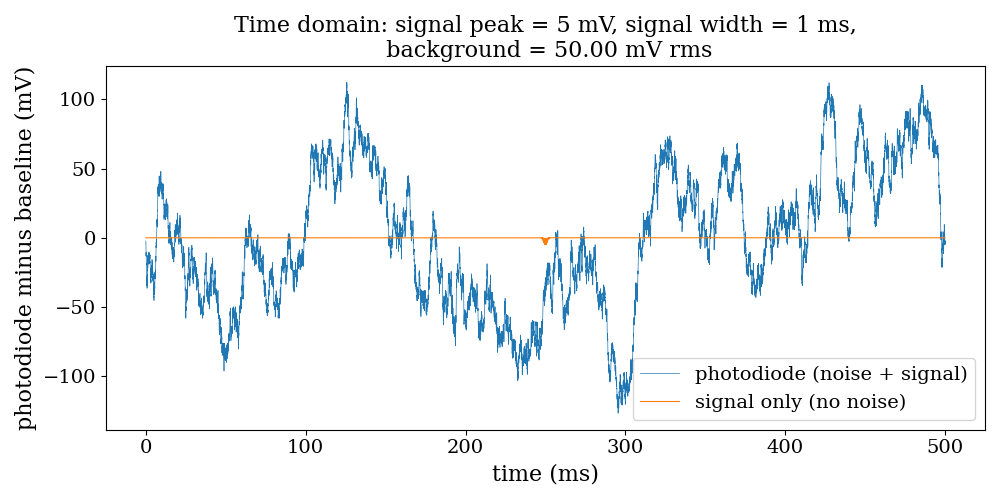

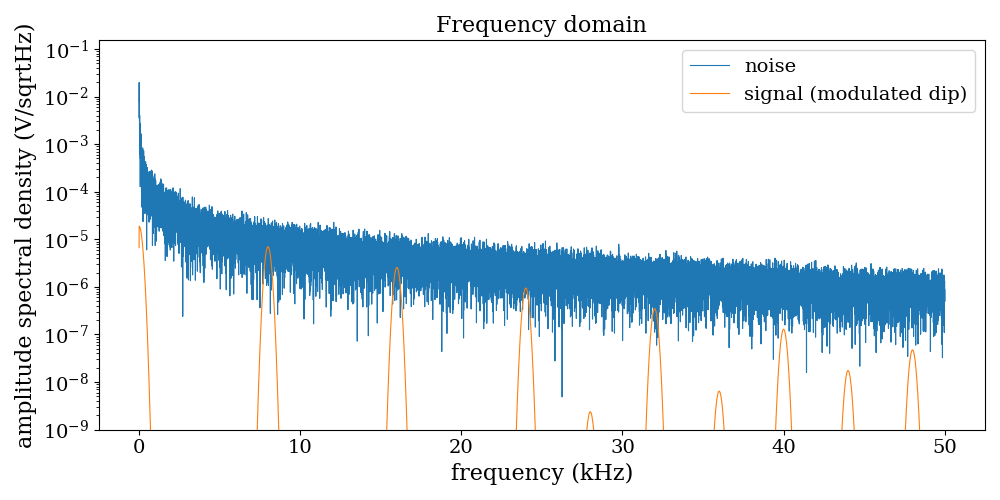

In [21]:
# ---------------- parameters ----------------
# sampling
fs_Hz = 100e3
duration_s = .5

# atomic resonance
linewidth_MHz = 5.2

# modulation
mod_amp_MHz = 5.0
mod_freq_Hz = 4e3
mod_dc_MHz = 0.0
mod_phase_rad = 0.0

# modulation channel digitizing
MHz_per_V = 1000.0
mod_white_rms_V = 2e-3
mod_seed = 1

# time-of-flight signal
dip_depth_V = 0.005
t0_s = 0.25
sigma_t_s = 0.001

# background
baseline_V = 7.0
white_asd_V_rtHz = 0*22.4e-6      # 22.4 uV/rtHz over 0-50 kHz = 5 mV rms
white_hpf_Hz = None             # white noise only above this (None -> from DC)
white_lpf_Hz = None             # white noise only below this (None -> up to fs/2)
drift_rms_V = 0.05            # slow noise off; set e.g. 0.010 to play
drift_corner_Hz = 50000.0
slow_amp_V = 0.0
slow_freq_Hz = 100.0
bg_seed = 7

# digitizer (shared)
adc_range_V = 10.0
adc_bits = 16

# ---------------- compute ----------------
t = np.arange(int(round(duration_s * fs_Hz))) / fs_Hz

delta_true = modulation(t, amp_MHz=mod_amp_MHz, freq_Hz=mod_freq_Hz,
                        dc_MHz=mod_dc_MHz, phase_rad=mod_phase_rad)
v_mod, delta_meas = digitize_modulation(
    delta_true, MHz_per_V=MHz_per_V, white_rms_V=mod_white_rms_V,
    adc_range_V=adc_range_V, adc_bits=adc_bits, seed=mod_seed)
ref = fit_reference(t, v_mod, f_guess_Hz=mod_freq_Hz)
delta_fit = MHz_per_V * (ref['offset_V'] +
                         ref['amp_V'] * np.sin(2 * np.pi * ref['f_Hz'] * t + ref['phase_rad']))

dip = tof_dip(t, delta_true, dip_depth_V=dip_depth_V, t0_s=t0_s,
              sigma_t_s=sigma_t_s, linewidth_MHz=linewidth_MHz)

bg = tof_background(t, baseline_V=baseline_V, white_asd_V_rtHz=white_asd_V_rtHz,
                    white_hpf_Hz=white_hpf_Hz, white_lpf_Hz=white_lpf_Hz,
                    drift_rms_V=drift_rms_V, drift_corner_Hz=drift_corner_Hz,
                    slow_amp_V=slow_amp_V, slow_freq_Hz=slow_freq_Hz, seed=bg_seed)

v = digitize(bg - dip, adc_range_V, adc_bits)   # what the digitizer records

print(f"reference fit: f = {ref['f_Hz']:.4f} Hz (set {mod_freq_Hz:.1f}), "
      f"amp = {ref['amp_V'] * MHz_per_V:.3f} MHz (set {mod_amp_MHz:.1f}), "
      f"phase = {ref['phase_rad']:.4f} rad (set {mod_phase_rad:.4f})")
print(f"background noise rms = {np.std(bg - baseline_V) * 1e3:.2f} mV")

# ---------------- plot ----------------
# modulation: digitized and fit, first 5 periods
if 0:
    plt.figure(figsize=(10, 5))
    plt.axhspan(-linewidth_MHz / 2, linewidth_MHz / 2, color='C2', alpha=0.2, label='resonance FWHM')
    plt.plot(t * 1e3, delta_meas, '.', ms=4, label='digitized modulation')
    plt.plot(t * 1e3, delta_fit, lw=1, label='fit')
    plt.xlim(0, 5 / mod_freq_Hz * 1e3)
    plt.xlabel('time (ms)')
    plt.ylabel('detuning (MHz)')
    plt.title('Modulation, first 5 periods')
    plt.legend()
    plt.tight_layout()


# time domain: photodiode
if 1:
    plt.figure(figsize=(10, 5))
    plt.plot(t * 1e3, (v - baseline_V) * 1e3, lw=0.5, label='photodiode (noise + signal)')
    plt.plot(t * 1e3, -dip * 1e3, lw=0.8, label='signal only (no noise)')
    plt.xlabel('time (ms)')
    plt.ylabel('photodiode minus baseline (mV)')
    plt.title(f'Time domain: signal peak = {dip_depth_V * 1e3:.0f} mV, '
            f'signal width = {sigma_t_s * 1e3:.0f} ms,\n '
            f'background = {np.std(bg - baseline_V) * 1e3:.2f} mV rms')
    plt.legend()
    plt.tight_layout()

# time domain: only bg
if 0:
    plt.figure(figsize=(10, 5))
    plt.plot(t * 1e3, (bg - baseline_V) * 1e3, lw=0.5, label='photodiode (noise + signal)')
    plt.xlabel('time (ms)')
    plt.ylabel('photodiode minus baseline (mV)')
    plt.title(f'Time domain: Only Background \n'
            f'background = {np.std(bg - baseline_V) * 1e3:.2f} mV rms')
    plt.tight_layout()

# frequency domain: noise and signal
if 1:
    f_n, psd_n = signal.periodogram(bg - baseline_V, fs=fs_Hz, window='hann')
    f_s, psd_s = signal.periodogram(dip, fs=fs_Hz, window='hann')

    plt.figure(figsize=(10, 5))
    plt.semilogy(f_n / 1e3, np.sqrt(psd_n), lw=0.8, label='noise')
    plt.semilogy(f_s / 1e3, np.sqrt(psd_s), lw=0.8, label='signal (modulated dip)')
    plt.ylim(1e-9, None)
    plt.xlabel('frequency (kHz)')
    plt.ylabel('amplitude spectral density (V/sqrtHz)')
    plt.title(f'Frequency domain')
    #plt.title(f'Frequency domain, f_mod = {mod_freq_Hz / 1e3:.0f} kHz')
    plt.legend()
    plt.tight_layout()

# frequency domain: only bg
if 0:
    f_n, psd_n = signal.periodogram(bg - baseline_V, fs=fs_Hz, window='hann')

    plt.figure(figsize=(10, 5))
    plt.semilogy(f_n / 1e3, np.sqrt(psd_n), lw=0.8, label='background')
    plt.ylim(1e-9, None)
    plt.xlabel('frequency (kHz)')
    plt.ylabel('amplitude spectral density (V/sqrtHz)')
    plt.title(f'Frequency domain: Only Background \n'
              f'background = {np.std(bg - baseline_V) * 1e3:.2f} mV rms, '
              f'white density = {white_asd_V_rtHz * 1e6:.1f} uV/sqrtHz')
    plt.tight_layout()

lock-in, harmonic 2: peak = 0.32 mV, noise = 0.091 mV rms, signal/noise = 3.5


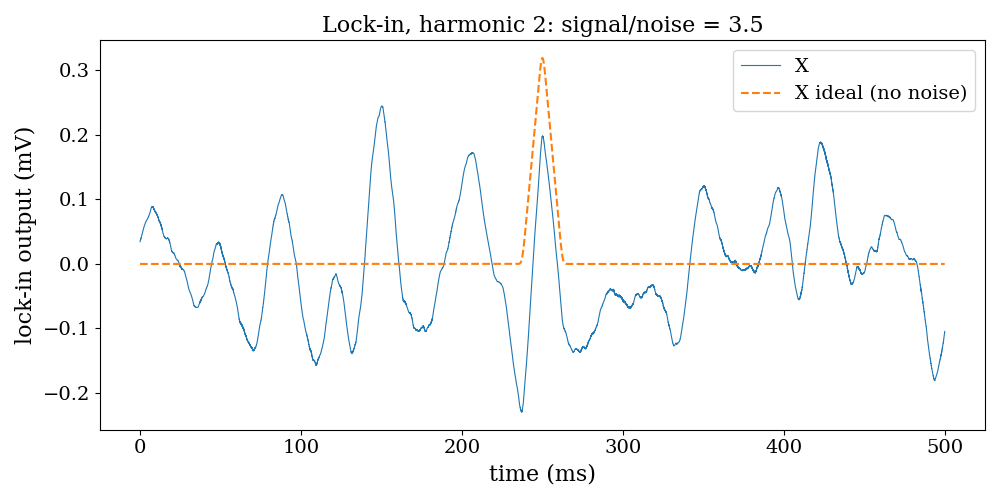

In [22]:
# ---------------- parameters ----------------
lockin_harmonic = 2
lockin_n_periods = 50


# ---------------- compute ----------------
X, Y, N = lock_in(t, v, ref['f_Hz'], ref['phase_rad'], lockin_harmonic, lockin_n_periods)

# ground truth: noiseless dip, true reference
X_ideal, _, _ = lock_in(t, baseline_V - dip, mod_freq_Hz, mod_phase_rad,
                        lockin_harmonic, lockin_n_periods)

valid = slice(N, -N)   # drop filter edge effects
snr = X_ideal.max() / np.std((X - X_ideal)[valid])
print(f"lock-in, harmonic {lockin_harmonic}: peak = {X_ideal.max() * 1e3:.2f} mV, "
      f"noise = {np.std((X - X_ideal)[valid]) * 1e3:.3f} mV rms, signal/noise = {snr:.1f}")

# ---------------- plot ----------------
plt.figure(figsize=(10, 5))
plt.plot(t * 1e3, X * 1e3, lw=0.8, label='X')
plt.plot(t * 1e3, X_ideal * 1e3, lw=1.5, ls='--', label='X ideal (no noise)')
plt.xlabel('time (ms)')
plt.ylabel('lock-in output (mV)')
plt.title(f'Lock-in, harmonic {lockin_harmonic}: signal/noise = {snr:.1f}')
plt.legend()
plt.tight_layout()